# Notebook 1 – Exploración y Preprocesamiento de Datos

En este notebook realizo la exploración inicial, validación y preprocesamiento del dataset de empleados
con el objetivo de preparar los datos para el modelado predictivo de la rotación (Attrition).
Es importante indicar que este dataset ya fué analizado en el proyecto EDA, por lo que en este notebook ralizaré pequeñas revisiones y confirmaciones.
El dataset inicial fue analizado y limpiado, se generaron nuevas variables y se guardó la versión limpia como df_corregida_proxy.

In [2]:
# Carga y exploración inicial del dataset PROCESADO (proveniente del proyecto EDA)
import pandas as pd
df_corregida_proxy = pd.read_csv('../data/processed/df_corregida_proxy.csv')

df_corregida_proxy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 41 columns):
 #   Column                        Non-Null Count  Dtype 
---  ------                        --------------  ----- 
 0   Age                           1470 non-null   int64 
 1   Attrition                     1470 non-null   int64 
 2   BusinessTravel                1470 non-null   object
 3   DailyRate                     1470 non-null   int64 
 4   Department                    1470 non-null   object
 5   DistanceFromHome              1470 non-null   int64 
 6   Education                     1470 non-null   int64 
 7   EducationField                1470 non-null   object
 8   EnvironmentSatisfaction       1470 non-null   int64 
 9   Gender                        1470 non-null   object
 10  HourlyRate                    1470 non-null   int64 
 11  JobInvolvement                1470 non-null   int64 
 12  JobLevel                      1470 non-null   int64 
 13  JobRole           

In [3]:
# Revision descripción de variables numéricas
df_corregida_proxy.describe().T   

,count,mean,std,min,25%,50%,75%,max
Age,1470.0,36.923810,9.135373,18.0,30.0,36.0,43.00,60.0
Attrition,1470.0,0.161224,0.367863,0.0,0.0,0.0,0.00,1.0
DailyRate,1470.0,802.485714,403.509100,102.0,465.0,802.0,1157.00,1499.0
DistanceFromHome,1470.0,9.192517,8.106864,1.0,2.0,7.0,14.00,29.0
Education,1470.0,2.912925,1.024165,1.0,2.0,3.0,4.00,5.0
EnvironmentSatisfaction,1470.0,2.721769,1.093082,1.0,2.0,3.0,4.00,4.0
HourlyRate,1470.0,65.891156,20.329428,30.0,48.0,66.0,83.75,100.0
JobInvolvement,1470.0,2.729932,0.711561,1.0,2.0,3.0,3.00,4.0
JobLevel,1470.0,2.063946,1.106940,1.0,1.0,2.0,3.00,5.0
JobSatisfaction,1470.0,2.728571,1.102846,1.0,2.0,3.0,4.00,4.0


In [4]:
# Revision descripción de variables categóricas
df_corregida_proxy.describe(include=['object']).T

,count,unique,top,freq
BusinessTravel,1470,3,Travel_Rarely,1043
Department,1470,3,Research & Development,961
EducationField,1470,6,Life Sciences,606
Gender,1470,2,Male,882
JobRole,1470,9,Sales Executive,326
MaritalStatus,1470,3,Married,673
Attrition_cat,1470,2,Se quedan,1233
burnout_risk_cat,1470,2,Bajo Riesgo,1345
cultura_positiva_cat,1470,2,Cultura Pobre,739
alto_engagement_cat,1470,2,Alto Engagement,1012


In [5]:
# Revisión de duplicados y missings

print(f"Duplicados totales: {df_corregida_proxy.duplicated().sum()}")
print(f"Valores nulos totales: {df_corregida_proxy.isnull().sum().sum()}")

if df_corregida_proxy.isnull().sum().sum() > 0:
    print("\nColumnas con nulos:")
    print(df_corregida_proxy.isnull().sum()[df_corregida_proxy.isnull().sum() > 0])

Duplicados totales: 0
Valores nulos totales: 0


In [6]:
'''Resumen estadístico del dataset:

--> El dataset está compuesto por 1.470 empleados, sin valores nulos ni registros duplicados tras el proceso de limpieza.

--> Las variables numéricas incluyen edad, experiencia, ingresos, satisfacción laboral y condiciones de trabajo.
    - La edad media es de ~37 años, con trayectorias laborales muy heterogéneas en términos de experiencia y antigüedad.
    - Los ingresos mensuales presentan alta dispersión y asimetría, con valores que oscilan entre ~1.000 y ~20.000.
    - Las métricas de satisfacción, engagement y clima laboral se concentran en valores intermedios (escalas de 1 a 4/5).
    - Aproximadamente el 28% de los empleados realiza horas extra (OverTime).
    - La variable objetivo Attrition es binaria y está desbalanceada, con una tasa de rotación cercana al 16%.

--> Las variables categóricas describen atributos organizativos y no presentan valores nulos.

--> Las variables proxy creadas durante el EDA capturan aspectos de burnout, cultura, engagement y desarrollo.
    - El riesgo de burnout afecta a un porcentaje reducido de empleados (~8.5%).
    - Las variables de alto engagement y cultura positiva presentan distribuciones equilibradas o claramente mayoritarias.
'''

'Resumen estadístico del dataset:\n\n--> El dataset está compuesto por 1.470 empleados, sin valores nulos ni registros duplicados tras el proceso de limpieza.\n\n--> Las variables numéricas incluyen edad, experiencia, ingresos, satisfacción laboral y condiciones de trabajo.\n    - La edad media es de ~37 años, con trayectorias laborales muy heterogéneas en términos de experiencia y antigüedad.\n    - Los ingresos mensuales presentan alta dispersión y asimetría, con valores que oscilan entre ~1.000 y ~20.000.\n    - Las métricas de satisfacción, engagement y clima laboral se concentran en valores intermedios (escalas de 1 a 4/5).\n    - Aproximadamente el 28% de los empleados realiza horas extra (OverTime).\n    - La variable objetivo Attrition es binaria y está desbalanceada, con una tasa de rotación cercana al 16%.\n\n--> Las variables categóricas describen atributos organizativos y no presentan valores nulos.\n\n--> Las variables proxy creadas durante el EDA capturan aspectos de burn

In [7]:
# Análisis de variable objetivo (Attrition) - distribución

import matplotlib.pyplot as plt

# Cálculo de cada resultado y su porcentaje
attrition_counts = df_corregida_proxy['Attrition'].value_counts()
attrition_percent = df_corregida_proxy['Attrition'].value_counts(normalize=True) * 100

print(f"No rotación (Attrition No / 0): {attrition_counts[0]} empleados ({attrition_percent[0]:.1f}%)")
print(f"Rotación (Attrition Yes / 1): {attrition_counts[1]} empleados ({attrition_percent[1]:.1f}%)")


No rotación (Attrition No / 0): 1233 empleados (83.9%)
Rotación (Attrition Yes / 1): 237 empleados (16.1%)


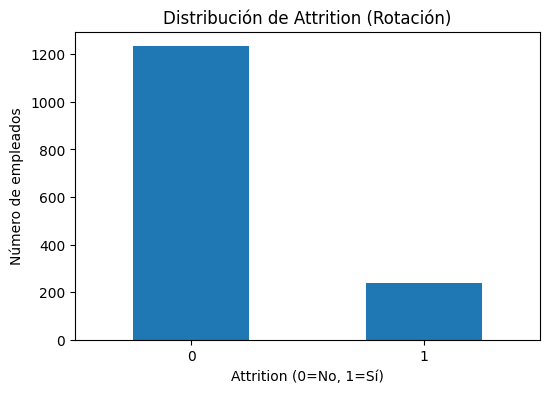

In [8]:
# Gráfico  
plt.figure(figsize=(6,4))
df_corregida_proxy['Attrition'].value_counts().plot(kind='bar')
plt.title('Distribución de Attrition (Rotación)')
plt.xlabel('Attrition (0=No, 1=Sí)')
plt.ylabel('Número de empleados')
plt.xticks(rotation=0)
plt.show()

In [9]:
# Análisis univariante de features CLAVE (solo las importantes)

# Separación de variables por su tipo
numericas = df_corregida_proxy.select_dtypes(include=['int64', 'float64']).columns.tolist()
categoricas = df_corregida_proxy.select_dtypes(include=['object']).columns.tolist()

print(f"Variables numéricas: {len(numericas)}")
print(f"Variables categóricas: {len(categoricas)}")

# Eliminación de Attrition de las numéricas porque es el target

if 'Attrition' in numericas:
    numericas.remove('Attrition')

Variables numéricas: 29
Variables categóricas: 12


In [10]:
# Revisión de las variables proxy creadas en el EDA
proxy_vars = ['burnout_risk', 'cultura_positiva', 'alto_engagement', 
              'oportunidades_desarrollo', 'burnout_risk_cat', 
              'cultura_positiva_cat', 'alto_engagement_cat', 
              'oportunidades_desarrollo_cat']

print("Variables proxy creadas en el EDA:")
for var in proxy_vars:
    if var in df_corregida_proxy.columns:
        print(f"  ✓ {var}: {df_corregida_proxy[var].dtype}")

Variables proxy creadas en el EDA:
  ✓ burnout_risk: int64
  ✓ cultura_positiva: int64
  ✓ alto_engagement: int64
  ✓ oportunidades_desarrollo: int64
  ✓ burnout_risk_cat: object
  ✓ cultura_positiva_cat: object
  ✓ alto_engagement_cat: object
  ✓ oportunidades_desarrollo_cat: object


In [11]:
# Relaciones bivariantes CON TARGET (confirmación datos EDA)
'''
Notebook 4 - EDA

• HORAS EXTRAS:
  30.5% vs 10.4% se van
  → TRIPLICA probabilidad
  ✓ Variable 'OverTime' disponible para ML

• RIESGO DE BURNOUT:
  28.0% vs 15.0% se van
  → Casi duplica probabilidad
  ✓ Variable 'burnout_risk' disponible para ML

• CULTURA POSITIVA:
  19.2% vs 13.0% se van
  → Reduce rotación 1/3
  ✓ Variable 'cultura_positiva' disponible para ML

• ALTO ENGAGEMENT:
  21.6% vs 13.6% se van
  → Reduce significativamente
  ✓ Variable 'alto_engagement' disponible para ML

• OPORTUNIDADES DESARROLLO:
  20.8% vs 11.4% se van
  → Aumenta rotación
  ✓ Variable 'oportunidades_desarrollo' disponible para ML

'''


"\nNotebook 4 - EDA\n\n• HORAS EXTRAS:\n  30.5% vs 10.4% se van\n  → TRIPLICA probabilidad\n  ✓ Variable 'OverTime' disponible para ML\n\n• RIESGO DE BURNOUT:\n  28.0% vs 15.0% se van\n  → Casi duplica probabilidad\n  ✓ Variable 'burnout_risk' disponible para ML\n\n• CULTURA POSITIVA:\n  19.2% vs 13.0% se van\n  → Reduce rotación 1/3\n  ✓ Variable 'cultura_positiva' disponible para ML\n\n• ALTO ENGAGEMENT:\n  21.6% vs 13.6% se van\n  → Reduce significativamente\n  ✓ Variable 'alto_engagement' disponible para ML\n\n• OPORTUNIDADES DESARROLLO:\n  20.8% vs 11.4% se van\n  → Aumenta rotación\n  ✓ Variable 'oportunidades_desarrollo' disponible para ML\n\n"

In [12]:
# Validación numérica rápida del hallazgo más fuerte -> OverTime (hallazgo #1)
overtime_yes = df_corregida_proxy[df_corregida_proxy['OverTime'] == 1]['Attrition'].mean() * 100
overtime_no = df_corregida_proxy[df_corregida_proxy['OverTime'] == 0]['Attrition'].mean() * 100

print(f"Horas extras (OverTime):")
print(f"  • Con horas extras: {overtime_yes:.1f}% rotación")
print(f"  • Sin horas extras: {overtime_no:.1f}% rotación")
print(f"  • Relación: {overtime_yes/overtime_no:.1f}x")

# 3. Conclusión
    # Se confirman los hallazgos del EDA
    # Las variables proxy creadas están disponibles

Horas extras (OverTime):
  • Con horas extras: 30.5% rotación
  • Sin horas extras: 10.4% rotación
  • Relación: 2.9x


In [13]:
# Revisión y limpieza (eliminar redundancias)

# Identificar columnas redundantes (_cat)
columnas_redundantes = [col for col in df_corregida_proxy.columns if col.endswith('_cat')]

print(f"Columnas que terminan en '_cat' ({len(columnas_redundantes)}):")
for col in columnas_redundantes:
    # Mostrar qué variable numérica correspondiente tienen
    base_name = col.replace('_cat', '')
    if base_name in df_corregida_proxy.columns:
        print(f"  • {col:35} → redundante con: {base_name}")
    else:
        print(f"  • {col:35} → no tiene equivalente numérico")


Columnas que terminan en '_cat' (6):
  • Attrition_cat                       → redundante con: Attrition
  • burnout_risk_cat                    → redundante con: burnout_risk
  • cultura_positiva_cat                → redundante con: cultura_positiva
  • alto_engagement_cat                 → redundante con: alto_engagement
  • oportunidades_desarrollo_cat        → redundante con: oportunidades_desarrollo
  • OverTime_cat                        → redundante con: OverTime


In [14]:
# Eliminar redundancias
df_ML = df_corregida_proxy.drop(columns=columnas_redundantes)

print(f"Dataset original: {df_corregida_proxy.shape[1]} columnas")
print(f"Dataset limpio:   {df_ML.shape[1]} columnas")
print(f"Columnas eliminadas: {len(columnas_redundantes)}")


Dataset original: 41 columnas
Dataset limpio:   35 columnas
Columnas eliminadas: 6


In [15]:
# Verificar qué ha quedado de la limpieza
print(f"• Total columnas: {df_ML.shape[1]}")
print(f"• Total filas: {df_ML.shape[0]}")

# Contar tipos de variables
numericas = df_ML.select_dtypes(include=['int64', 'float64']).columns.tolist()
categoricas = df_ML.select_dtypes(include=['object']).columns.tolist()

print(f"• Variables numéricas: {len(numericas)}")
print(f"• Variables categóricas: {len(categoricas)}")


• Total columnas: 35
• Total filas: 1470
• Variables numéricas: 29
• Variables categóricas: 6


In [ ]:
import os
import pickle

# Identificar variables

# Variables numéricas predictoras (excluyendo Attrition)
variables_numericas = [col for col in df_ML.columns 
                       if df_ML[col].dtype in ['int64', 'float64'] 
                       and col != 'Attrition']

# Clasificación de variables numéricas
continuas = []
ordinales = []
binarias = []

for var in variables_numericas:
    valores_unicos = df_ML[var].nunique()
    
    if valores_unicos == 2 and set(df_ML[var].unique()).issubset({0, 1}):
        binarias.append(var)
    elif valores_unicos <= 10:
        ordinales.append(var)
    else:
        continuas.append(var)

# Variables categóricas de texto
categoricas_texto = df_ML.select_dtypes(include=['object']).columns.tolist()

# Variables proxy creadas en EDA
proxy_vars = ['burnout_risk', 'cultura_positiva', 'alto_engagement', 
              'oportunidades_desarrollo', 'OverTime']

# Mostrar detalle

print(f"Total variables numéricas predictoras: {len(variables_numericas)}\n")

print(f"1. VARIABLES BINARIAS (0/1) -> {len(binarias)}:")
for var in sorted(binarias):
    print(f"   • {var:25} valores: {df_ML[var].unique()}")

print(f"\n2. VARIABLES ORDINALES (pocos valores) -> {len(ordinales)}:")
for var in sorted(ordinales):
    print(f"   • {var:25} valores: {sorted(df_ML[var].unique())}")

print(f"\n3. VARIABLES CONTINUAS (muchos valores) -> {len(continuas)}:")
for var in sorted(continuas):
    print(f"   • {var:25} rango: {df_ML[var].min():.0f} -> {df_ML[var].max():.0f}")

print(f"\n{'='*70}\nVARIABLES PROXY CREADAS EN EDA:\n{'='*70}")
for proxy in proxy_vars:
    if proxy in df_ML.columns:
        tipo = "DESCONOCIDO"
        if proxy in binarias:
            tipo = "BINARIA (0/1)"
        elif proxy in ordinales:
            tipo = "ORDINAL"
        elif proxy in continuas:
            tipo = "CONTINUA"
        print(f"• {proxy:25} → {tipo:15} valores: {sorted(df_ML[proxy].unique())}")

# Resumen y metadatos

print("\nRESUMEN DE CLASIFICACIÓN:")
print(f"• Variables continuas:      {len(continuas)}")
print(f"• Variables ordinales:      {len(ordinales)}")
print(f"• Variables binarias:       {len(binarias)}")
print(f"• Variables categóricas:    {len(categoricas_texto)}")
print(f"• Variables proxy:          {len([p for p in proxy_vars if p in df_ML.columns])}")
print(f"• Target:                   Attrition")
print(f"• TOTAL COLUMNAS:           {df_ML.shape[1]}")

# Guardar metadatos
ruta_metadatos = "../data/metadata"
os.makedirs(ruta_metadatos, exist_ok=True)

clasificacion = {
    'continuas': continuas,
    'ordinales': ordinales,
    'binarias': binarias,
    'categoricas_texto': categoricas_texto,
    'proxy_vars': proxy_vars,
    'target': 'Attrition'
}

with open(os.path.join(ruta_metadatos, 'clasificacion_variables.pkl'), 'wb') as f:
    pickle.dump(clasificacion, f)


Total variables numéricas predictoras: 28

1. VARIABLES BINARIAS (0/1) -> 5:
   • OverTime                  valores: [1 0]
   • alto_engagement           valores: [1 0]
   • burnout_risk              valores: [0 1]
   • cultura_positiva          valores: [0 1]
   • oportunidades_desarrollo  valores: [0 1]

2. VARIABLES ORDINALES (pocos valores) -> 11:
   • Education                 valores: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
   • EnvironmentSatisfaction   valores: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
   • JobInvolvement            valores: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
   • JobLevel                  valores: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
   • JobSatisfaction           valores: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
   • NumCompaniesWorked        valores: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8

In [17]:
# Separar target
target = 'Attrition'
if target in numericas:
    numericas.remove(target)
    print(f"• Variables predictoras numéricas: {len(numericas)}")
    print(f"• Variable objetivo: {target} (binaria)")


• Variables predictoras numéricas: 28
• Variable objetivo: Attrition (binaria)


In [42]:
# Guardar dataset limpio y validado
df_ML.to_csv("C:/Users/usuario/Desktop/Susana/Bootcamp/ML/GitHub_proyecto_ML/data/processed/df_ML.csv",index=False)
print("Dataset limpio guardado como df_ML.csv")

Dataset limpio guardado como df_ML.csv


### RESUMEN DEL NOTEBOOK

* Dataset cargado: 1,470 empleados, 41 variables iniciales
* Attrition: 16.1% rotación (237 casos), 83.9% no rotación (1,233 casos)
* Sin duplicados ni valores nulos
* Variables proxy creadas confirmadas (4 numéricas + 4 categóricas redundantes)
* Hallazgo EDA confirmado: OverTime triplica rotación (30.5% vs 10.4%)
* Eliminadas 6 variables redundantes (_cat)
* Dataset final: 35 variables (29 numéricas + 6 categóricas + 1 target)


Este notebook deja el dataset preparado para modelado supervisado.